# Inference of the cell-cell communication in the toy model with all observations

The function `Inference_CCC` instantiates the BoNesis inference problem from the compressed observation dataframe. It takes three inputs derived from the PSS sequence:

1. **Search space**: the bipartite dependency structure of the toy model. Each receptor node (`R1_A`, `R2_A`, `R1_B`, `R2_B`) is allowed to depend on any ligand from any cell type. Each ligand node (`L1_A`–`L4_A`, `L1_B`–`L4_B`) is restricted to depend only on the receptors of its own cell. No prior constraint is placed on the sign or existence of specific interactions within these structural rules.

2. **Observations**: the five PSS in `compr_obs_df`, encoding the measured sequence of receptor and ligand states across both cell types.

3. **Dynamical constraints**: for each consecutive PSS transition $\text{PSS}_t \to \text{PSS}_{t+1}$, two fixed-point constraints are added under `bo.fixed`/`bo.mutant`:
   - *Slow step* ($R \to L$): receptors are frozen at $R(T_t)$ and ligands must reach $L(T_{t+1})$ as a fixed point, encoding slow intracellular ligand secretion.
   - *Fast step* ($L \to R$): ligands are frozen at $L(T_{t+1})$ and receptors must reach $R(T_{t+1})$ as a fixed point, encoding fast receptor activation.

`enumerate_100bns_with_igs` then exhaustively enumerates all Boolean networks (up to `limit_bns`) and their minimal influence graphs (up to `limit_igs`) consistent with these constraints, using BoNesis under Most Permissive (MP) semantics.

In [18]:
from Inference_CCC import *

In [19]:
# Complete observations with one state changed at each time step
R_A = {
        'T1': {'R1_A': 1, 'R2_A': 0},
        'T2': {'R1_A': 1, 'R2_A': 0},
        'T3': {'R1_A': 1, 'R2_A': 1},
        'T4': {'R1_A': 1, 'R2_A': 1},
        'T5': {'R1_A': 0, 'R2_A': 1},
        'T6': {'R1_A': 0, 'R2_A': 1},
        'T7': {'R1_A': 0, 'R2_A': 1},
        'T8': {'R1_A': 0, 'R2_A': 1}
    }

R_B = {
        'T1': {'R1_B': 1, 'R2_B': 0},
        'T2': {'R1_B': 1, 'R2_B': 0},
        'T3': {'R1_B': 0, 'R2_B': 1},
        'T4': {'R1_B': 0, 'R2_B': 1},
        'T5': {'R1_B': 0, 'R2_B': 0},
        'T6': {'R1_B': 0, 'R2_B': 0},
        'T7': {'R1_B': 1, 'R2_B': 1},
        'T8': {'R1_B': 1, 'R2_B': 1}
    }

L_A = {
        'T1': {'L1_A': 1, 'L2_A': 0, 'L3_A': 0, 'L4_A': 0},
        'T2': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T3': {'L1_A': 1, 'L2_A': 1, 'L3_A': 0, 'L4_A': 0},
        'T4': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T5': {'L1_A': 1, 'L2_A': 1, 'L3_A': 1, 'L4_A': 0},
        'T6': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T7': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1},
        'T8': {'L1_A': 0, 'L2_A': 0, 'L3_A': 0, 'L4_A': 1}
    }

L_B = {
        'T1': {'L1_B': 1, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T2': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T3': {'L1_B': 1, 'L2_B': 1, 'L3_B': 0, 'L4_B': 0},
        'T4': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T5': {'L1_B': 0, 'L2_B': 0, 'L3_B': 1, 'L4_B': 0},
        'T6': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T7': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0},
        'T8': {'L1_B': 0, 'L2_B': 0, 'L3_B': 0, 'L4_B': 1}
    }

R = {"A": R_A, "B": R_B}
L = {"A": L_A, "B": L_B}

# Create the observation data
obs_df, compr_obs_df, cells, influences, all_receptors, all_ligands = create_observation_data(R, L)
print("Original compressed observation dataframe:")
print(compr_obs_df)

Original compressed observation dataframe:
    R1_A  R2_A  R1_B  R2_B  L1_A  L2_A  L3_A  L4_A  L1_B  L2_B  L3_B  L4_B
T1     1     0     1     0  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>  <NA>
T2     1     1     0     1     1     1     0     0     1     1     0     0
T3     0     1     0     0     1     1     1     0     0     0     1     0
T4     0     1     1     1     0     0     0     1     0     0     0     0
T5  <NA>  <NA>  <NA>  <NA>     0     0     0     1     0     0     0     1


In [20]:
limit_igs = 500
limit_bns = 500

bo, nodes = ccc_bns_synthesis(compr_obs_df, cells, influences)
bns, igs = enumerate_100bns_with_igs(bo, nodes, limit_igs=limit_igs, limit_bns=limit_bns)
results = {}
results['bns'] = bns
results['igs'] = igs


print(f"   Found {len(bns)} functions, {len(igs)} influence graphs")

Enumerating up to 500 influence graphs with their Boolean networks...


Enumerating IG+BN pairs: 0it [00:00, ?it/s]

Grounding...

Enumerating IG+BN pairs: 1it [00:00,  2.43it/s]

done in 0.2s


Enumerating IG+BN pairs: 448it [00:02, 194.22it/s]

Found 448 influence graphs with their Boolean networks
Generating up to 500 additional diverse Boolean networks...
Grounding...

done in 0.1s
Found 500 solutions in 68.4s (first in 0.1s; rate 0.1s)Generated 500 additional diverse Boolean networks
Total: 948 Boolean networks
   Found 948 functions, 448 influence graphs


## Stacked influence graph (Figure 4)

From the enumerated ensemble of Boolean networks, we derive one **minimal influence graph** (IG) per network. A minimal IG retains only the interactions that are strictly necessary: removing any single edge would yield a graph no longer compatible with the observations.

The 448 individual IGs are aggregated into a single **stacked influence graph** by counting, for each directed signed edge $(u \xrightarrow{\pm} v)$, how many of the 448 networks contain it. The count on each edge thus reflects how constrained that regulatory interaction is by the data:

- **Edges present in all 448 networks** are *core*: the observed dynamics require them regardless of which specific BN is chosen.
- **Edges present in a subset** are *variable*: multiple alternative wiring patterns are compatible with the data.

The node layout places receptors at the top and ligands at the bottom, separating the two cell types horizontally. This layout makes the bipartite $L \to R$ (cross-cell, variable) and $R \to L$ (within-cell, core) layers visually explicit.

`plot_influence_graphs` renders the stacked IG with edge weights annotated directly on each arrow, using blue solid arrows for activations and orange dashed T-arrows for inhibitions.

In [44]:
node_positions = {
    # Cell A — receptors (top row)
    'R1_A': (100, 50),
    'R2_A': (250, 50),
    # Cell B — receptors (top row)
    'R1_B': (425, 50),
    'R2_B': (550, 50),
    # Cell A — ligands (bottom row)
    'L1_A': (25,  300),
    'L2_A': (100, 300),
    'L3_A': (175, 300),
    'L4_A': (250, 300),
    # Cell B — ligands (bottom row)
    'L1_B': (375, 300),
    'L2_B': (450, 300),
    'L3_B': (525, 300),
    'L4_B': (600, 300),
}
    
plot_influence_graphs(results['igs'], node_positions=node_positions)

CytoscapeWidget(cytoscape_layout={'name': 'preset', 'animate': True}, cytoscape_style=[{'selector': 'node', 's…

## MaBoSS simulation setup


All 448 inferred Boolean networks are exported to MaBoSS format using `bns_to_maboss`. For the toy model, no phenotype nodes are defined: all 12 nodes (receptors and ligands of both cells) are included directly as simulation variables and shown in the output trajectories. The initial state corresponds to the first observed PSS: R1_A=1, R2_A=0, R1_B=1, R2_B=0, L1_A=1, L2_A=0, L3_A=0, L4_A=0, L1_B=1, L2_B=0, L3_B=0, L4_B=0. Each model is written as a `.bnd`/`.cfg` pair and a `.bnet` file to a dedicated subdirectory under `toy_model_maboss/`.

In [45]:
import os
import pandas as pd
from pathlib import Path


# ─────────────────────────────────────────────────────────────────────────────
# Boolean expression translator: BoNesis → MaBoSS syntax
# ─────────────────────────────────────────────────────────────────────────────

def bonesis_to_maboss_logic(expr: str) -> str:
    if expr is None or str(expr).strip() == "":
        return "0"
    expr = str(expr).strip()
    if expr in ("True", "1", "true"):
        return "1"
    if expr in ("False", "0", "false"):
        return "0"
    return expr


# ─────────────────────────────────────────────────────────────────────────────
# .bnd file generator
# ─────────────────────────────────────────────────────────────────────────────

def generate_bnd(model_row: pd.Series,
                 phenotypes: dict | None = None) -> str:
    lines = []

    def write_node(node, func):
        logic = bonesis_to_maboss_logic(func)
        lines.append(f"Node {node} {{")
        lines.append(f"  logic = ({logic});")
        lines.append(f"  rate_up = @logic ? $u_{node} : 0;")
        lines.append(f"  rate_down = @logic ? 0 : $d_{node};")
        lines.append("}")
        lines.append("")

    for node, func in model_row.items():
        write_node(node, func)

    if phenotypes:
        lines.append("// ── Phenotype (output) nodes ──────────────────────────────────────")
        lines.append("")
        for node, func in phenotypes.items():
            write_node(node, func)

    return "\n".join(lines)


# ─────────────────────────────────────────────────────────────────────────────
# .cfg file generator 
# ─────────────────────────────────────────────────────────────────────────────

def generate_cfg(bn_nodes: list,
                 phenotype_nodes: list | None = None,
                 initial_state: dict | None = None,
                 time_tick: float = 0.1,
                 max_time: float = 4,
                 sample_count: int = 10000) -> str:
    all_nodes = list(bn_nodes) + list(phenotype_nodes or [])
    initial_state = initial_state or {}
    use_phenotypes = bool(phenotype_nodes)
    lines = []

    # Rate parameters for all nodes
    for node in all_nodes:
        lines.append(f"$u_{node} = 1;")
        lines.append(f"$d_{node} = 1;")
    lines.append("")

    if use_phenotypes:
        # BN nodes → internal (hidden from output)
        lines.append("// BN nodes: internal (not shown in output)")
        for node in bn_nodes:
            lines.append(f"{node}.is_internal = 1;")
        lines.append("")

        # Phenotype nodes → external (shown in output)
        lines.append("// Phenotype nodes: external (shown in output)")
        for node in phenotype_nodes:
            lines.append(f"{node}.is_internal = 0;")
        lines.append("")
    else:
        # No phenotypes: show all BN nodes in output
        lines.append("// No phenotype nodes: all BN nodes shown in output")
        for node in bn_nodes:
            lines.append(f"{node}.is_internal = 0;")
        lines.append("")

    # Initial states
    lines.append("// Initial states")
    for node in all_nodes:
        val = initial_state.get(node, 0)
        lines.append(f"{node}.istate = {int(val)};")
    lines.append("")

    # Simulation parameters
    lines += [
        f"time_tick = {time_tick};",
        f"max_time = {max_time};",
        f"sample_count = {sample_count};",
        "discrete_time = 0;",
        "use_physrandgen = 1;",
        "seed_pseudorandom = 0;",
        "display_traj = 0;",
        "statdist_traj_count = 0;",
        "statdist_cluster_threshold = 1;",
        "thread_count = 1;",
        "statdist_similarity_cache_max_size = 20000;",
    ]

    return "\n".join(lines) + "\n"


# ─────────────────────────────────────────────────────────────────────────────
# .cfg file generator  
# ─────────────────────────────────────────────────────────────────────────────

def generate_bnet(model_row: pd.Series) -> str:
    return "\n".join(f"{node}, {func}" for node, func in model_row.items())

In [ ]:
def bns_to_maboss(
    both_funcs: pd.DataFrame,
    phenotypes: dict | None = None,
    initial_state: dict | None = None,
    output_dir: str = "maboss_models",
    bnet_dir: str | None = None,
    prefix: str = "model",
    time_tick: float = 0.1,
    max_time: float = 4,
    sample_count: int = 10000,
    verbose: bool = True,
) -> list:
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    _bnet_path = Path(bnet_dir) if bnet_dir else output_path / "bnet"
    _bnet_path.mkdir(parents=True, exist_ok=True)

    bn_nodes = list(both_funcs.columns)
    phenotype_nodes = list(phenotypes.keys()) if phenotypes else []
    converted = []

    for i, (_, row) in enumerate(both_funcs.iterrows()):
        model_name = f"{prefix}_{i}"
        model_dir = output_path / model_name
        model_dir.mkdir(exist_ok=True)

        bnd_path = model_dir / f"{model_name}.bnd"
        cfg_path = model_dir / f"{model_name}.cfg"
        bnet_path = _bnet_path / f"{model_name}.bnet"

        bnd_path.write_text(generate_bnd(row, phenotypes))
        cfg_path.write_text(generate_cfg(
            bn_nodes=bn_nodes,
            phenotype_nodes=phenotype_nodes or None,
            initial_state=initial_state,
            time_tick=time_tick,
            max_time=max_time,
            sample_count=sample_count,
        ))
        bnet_path.write_text(generate_bnet(row))

        converted.append({
            "name": model_name,
            "bnd_path": str(bnd_path),
            "cfg_path": str(cfg_path),
            "bnet_path": str(bnet_path),
        })

        if verbose:
            print(f"  [{i+1}/{len(both_funcs)}] {bnd_path.name}, {cfg_path.name}, {bnet_path.name}")

    if verbose:
        print(f"\nDone. {len(converted)} model(s) written to '{output_dir}/' (bnet → '{_bnet_path}/')")

    return converted


In [47]:
initial_state = {
    'R1_A': 1, 'R2_A': 0,
    'R1_B': 1, 'R2_B': 0,
    'L1_A': 1, 'L2_A': 0, 'L3_A': 0, 'L4_A': 0,
    'L1_B': 1, 'L2_B': 0, 'L3_B': 0, 'L4_B': 0
}

In [48]:
converted = bns_to_maboss(
    both_funcs=results["bns"],
    output_dir="toy_model_maboss",  
    prefix="model", 
    max_time=20 
)

  [1/948] model_0.bnd, model_0.cfg, model_0.bnet
  [2/948] model_1.bnd, model_1.cfg, model_1.bnet
  [3/948] model_2.bnd, model_2.cfg, model_2.bnet
  [4/948] model_3.bnd, model_3.cfg, model_3.bnet
  [5/948] model_4.bnd, model_4.cfg, model_4.bnet
  [6/948] model_5.bnd, model_5.cfg, model_5.bnet
  [7/948] model_6.bnd, model_6.cfg, model_6.bnet
  [8/948] model_7.bnd, model_7.cfg, model_7.bnet
  [9/948] model_8.bnd, model_8.cfg, model_8.bnet
  [10/948] model_9.bnd, model_9.cfg, model_9.bnet
  [11/948] model_10.bnd, model_10.cfg, model_10.bnet
  [12/948] model_11.bnd, model_11.cfg, model_11.bnet
  [13/948] model_12.bnd, model_12.cfg, model_12.bnet
  [14/948] model_13.bnd, model_13.cfg, model_13.bnet
  [15/948] model_14.bnd, model_14.cfg, model_14.bnet
  [16/948] model_15.bnd, model_15.cfg, model_15.bnet
  [17/948] model_16.bnd, model_16.cfg, model_16.bnet
  [18/948] model_17.bnd, model_17.cfg, model_17.bnet
  [19/948] model_18.bnd, model_18.cfg, model_18.bnet
  [20/948] model_19.bnd, model_1

## Dynamical comparison of inferred models with AstroLogics

Although the 448 inferred networks are structurally distinct (they differ in their influence graphs), they may produce equivalent or near-equivalent dynamics. To assess this, we use AstroLogics, which computes pairwise dynamical distances between models by comparing their state transition graphs, then projects the ensemble onto a two-dimensional space via multidimensional scaling (MDS).

The PCA/MDS trajectory plot below shows one point per model, with lines connecting models that are dynamically close. All 448 models fall within a single continuous cloud with no discrete sub-clusters, confirming that the ensemble is dynamically homogeneous: despite structural variability in the L→R layer, the inferred networks produce equivalent long-term behaviors from the same initial condition.

Since all models are dynamically equivalent, any representative would yield the same simulation output. However, to illustrate the robustness of this conclusion and provide a maximally diverse sample for visualization, we select 4 models from the ensemble using a greedy maximin strategy: we iteratively pick the model that is furthest (in dynamical distance) from the already-selected set. This ensures the selected models span the widest dynamical range within the cluster.

In [ ]:
import astrologics as ast

model = ast.ensemble("/Users/victoriabruning/Library/Mobile Documents/com~apple~CloudDocs/PhD_Git/3_Build_the_BooleanModel/3B_ToyModels/_Code_Paper/toy_model_maboss/bnet/", project_name="toy_model")

In [59]:
model.create_simulation()

Simulation object created


Start simulation


  0%|          | 0/948 [00:00<?, ?it/s]

Simulation completed
Trajectory object created


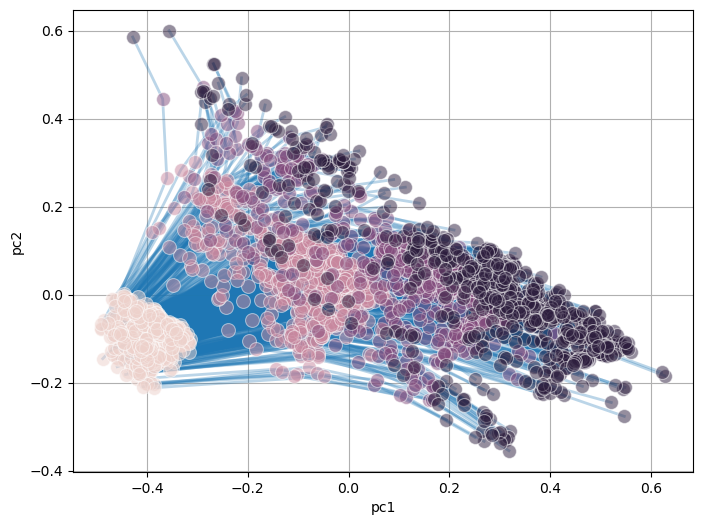

In [60]:
model.simulation.update_parameters(max_time=4, sample_count=10000)
model.simulation.run_simulation()

model.create_trajectory()
model.trajectory.pca_trajectory()
model.trajectory.plot_pca_trajectory(color="timepoint")

In [64]:
model.trajectory.calculate_distancematrix(mode = 'endpoint')
dist = model.trajectory.distance_matrix

Calculating distance matrix for endpoint simulation...
Distance matrix calculated successfully.


### Diverse model selection for visualization

The greedy maximin procedure `select_diverse_models` picks models that are maximally spread in dynamical distance space. Starting from the model with the highest average distance to all others (the most "outlying"), it iteratively adds the model furthest from the current selection. The 4 selected models are then simulated individually with MaBoSS.

In [65]:
def select_diverse_models(dist_df, n=4, seed_model=None):
    """
    Greedy maximin: iteratively pick the model maximally distant
    from the already-selected set.
    """
    models = list(dist_df.index)
    
    # Start from the model with the highest average distance (most "outlying")
    if seed_model is None:
        seed_model = dist_df.mean(axis=1).idxmax()
    
    selected = [seed_model]
    
    while len(selected) < n:
        # For each candidate, compute its minimum distance to any selected model
        remaining = [m for m in models if m not in selected]
        min_dists = dist_df.loc[remaining, selected].min(axis=1)
        # Pick the candidate with the largest such minimum distance
        next_model = min_dists.idxmax()
        selected.append(next_model)
    
    return selected

selected = select_diverse_models(dist, n=4)
print("Selected models:", selected)

# Show pairwise distances among selected
print("\nPairwise distances:")
print(dist.loc[selected, selected].round(3))

Selected models: ['model_911', 'model_594', 'model_502', 'model_518']

Pairwise distances:
model_id   model_911  model_594  model_502  model_518
model_id                                             
model_911      0.000      1.322      0.838      1.170
model_594      1.322      0.000      0.813      0.660
model_502      0.838      0.813      0.000      0.682
model_518      1.170      0.660      0.682      0.000


## MaBoSS node trajectories for representative models

We simulate three representative models (model_911, model_594, model_502 and model_518) individually with MaBoSS to illustrate the dynamical behavior of the inferred ensemble. Each simulation starts from the same initial PSS and runs for 20 time units. The full node trajectories, one curve per Boolean variable, are plotted for each model. Consistent with the AstroLogics result, the trajectories are qualitatively identical across models: transient activation of early receptors and ligands, followed by convergence to the attractor state where L4_A and L4_B dominate.

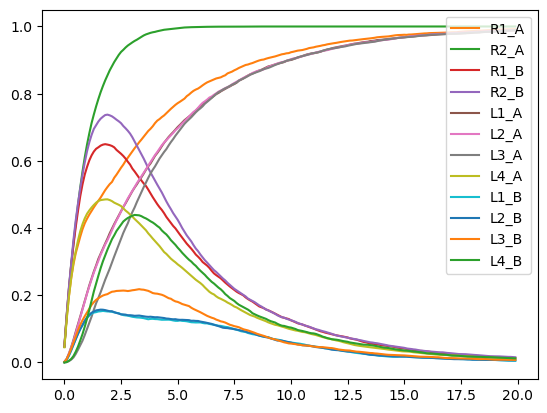

In [76]:
import maboss 
n_model = 911
base_path = f"/Users/victoriabruning/Library/Mobile Documents/com~apple~CloudDocs/PhD_Git/3_Build_the_BooleanModel/3B_ToyModels/_Code_Paper/toy_model_maboss/model_{n_model}/model_{n_model}"

# 1. Load model 
model_maboss = maboss.load(f"{base_path}.bnd", f"{base_path}.cfg")

# 2. MaBoSS run 
result = model_maboss.run()
result.plot_node_trajectory(legend=True)   

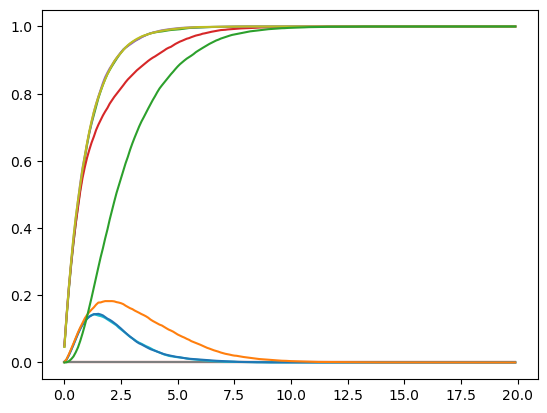

In [72]:
import maboss 
n_model = 594
base_path = f"/Users/victoriabruning/Library/Mobile Documents/com~apple~CloudDocs/PhD_Git/3_Build_the_BooleanModel/3B_ToyModels/_Code_Paper/toy_model_maboss/model_{n_model}/model_{n_model}"

# 1. Load model 
model_maboss = maboss.load(f"{base_path}.bnd", f"{base_path}.cfg")

# 2. MaBoSS run 
result = model_maboss.run()
result.plot_node_trajectory(legend=False)   

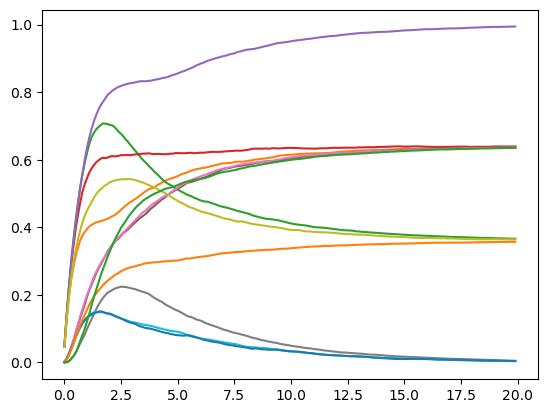

In [73]:
import maboss 
n_model = 502
base_path = f"/Users/victoriabruning/Library/Mobile Documents/com~apple~CloudDocs/PhD_Git/3_Build_the_BooleanModel/3B_ToyModels/_Code_Paper/toy_model_maboss/model_{n_model}/model_{n_model}"

# 1. Load model 
model_maboss = maboss.load(f"{base_path}.bnd", f"{base_path}.cfg")

# 2. MaBoSS run 
result = model_maboss.run()
result.plot_node_trajectory(legend=False)   

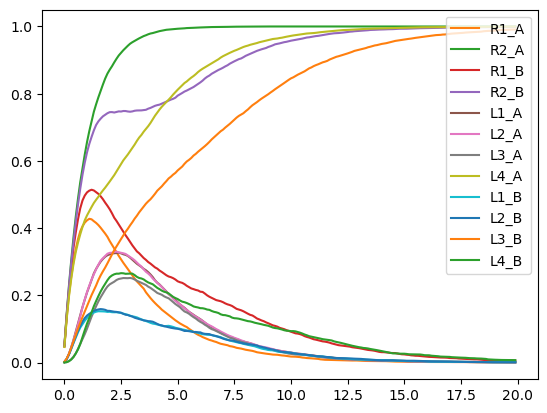

In [75]:
import maboss 
n_model = 518
base_path = f"/Users/victoriabruning/Library/Mobile Documents/com~apple~CloudDocs/PhD_Git/3_Build_the_BooleanModel/3B_ToyModels/_Code_Paper/toy_model_maboss/model_{n_model}/model_{n_model}"

# 1. Load model 
model_maboss = maboss.load(f"{base_path}.bnd", f"{base_path}.cfg")

# 2. MaBoSS run 
result = model_maboss.run()
result.plot_node_trajectory(legend=True)   